# Deepfake Audio Detection
A deep learning system to classify audio as Genuine (Human) or Deepfake (AI-Generated)

**Dataset:** The Fake-or-Real Dataset  
**Model:** Light CNN (LCNN)  
**Accuracy:** 88.90%

In [11]:

!pip install librosa soundfile onnxruntime scikit-learn matplotlib pandas tqdm

In [12]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import pandas as pd
import os
import json
import pickle
from pathlib import Path
from tqdm import tqdm
from sklearn.utils import resample
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, classification_report)
import warnings
warnings.filterwarnings('ignore')



## Phase 1 — Data Preparation
Load and explore the dataset, check class balance, and visualize audio samples.

In [13]:
BASE_PATH       = "C:/Users/tempadmin/Downloads/archive/for-norm/for-norm/"
TARGET_SR       = 16000
TARGET_DURATION = 2.0
TARGET_SAMPLES  = int(TARGET_SR * TARGET_DURATION)
N_MELS          = 64
HOP_LENGTH      = 256

print(f"Target sample rate:  {TARGET_SR} Hz")
print(f"Target duration:     {TARGET_DURATION}s")
print(f"Target samples:      {TARGET_SAMPLES}")

Target sample rate:  16000 Hz
Target duration:     2.0s
Target samples:      32000


In [14]:
def build_dataset(base_path):
    records = []
    for split in ['training', 'validation', 'testing']:
        for label in ['real', 'fake']:
            folder = Path(base_path) / split / label
            for file in folder.glob("*.wav"):
                records.append({
                    'file_path': str(file),
                    'label': 0 if label == 'real' else 1,
                    'label_name': label,
                    'split': split
                })
    return pd.DataFrame(records)

df = build_dataset(BASE_PATH)
print(f"Total files: {len(df)}")
print("\nClass distribution:")
print(df.groupby(['split', 'label_name']).size())

Total files: 69300

Class distribution:
split       label_name
testing     fake           2370
            real           2264
training    fake          26927
            real          26941
validation  fake           5398
            real           5400
dtype: int64


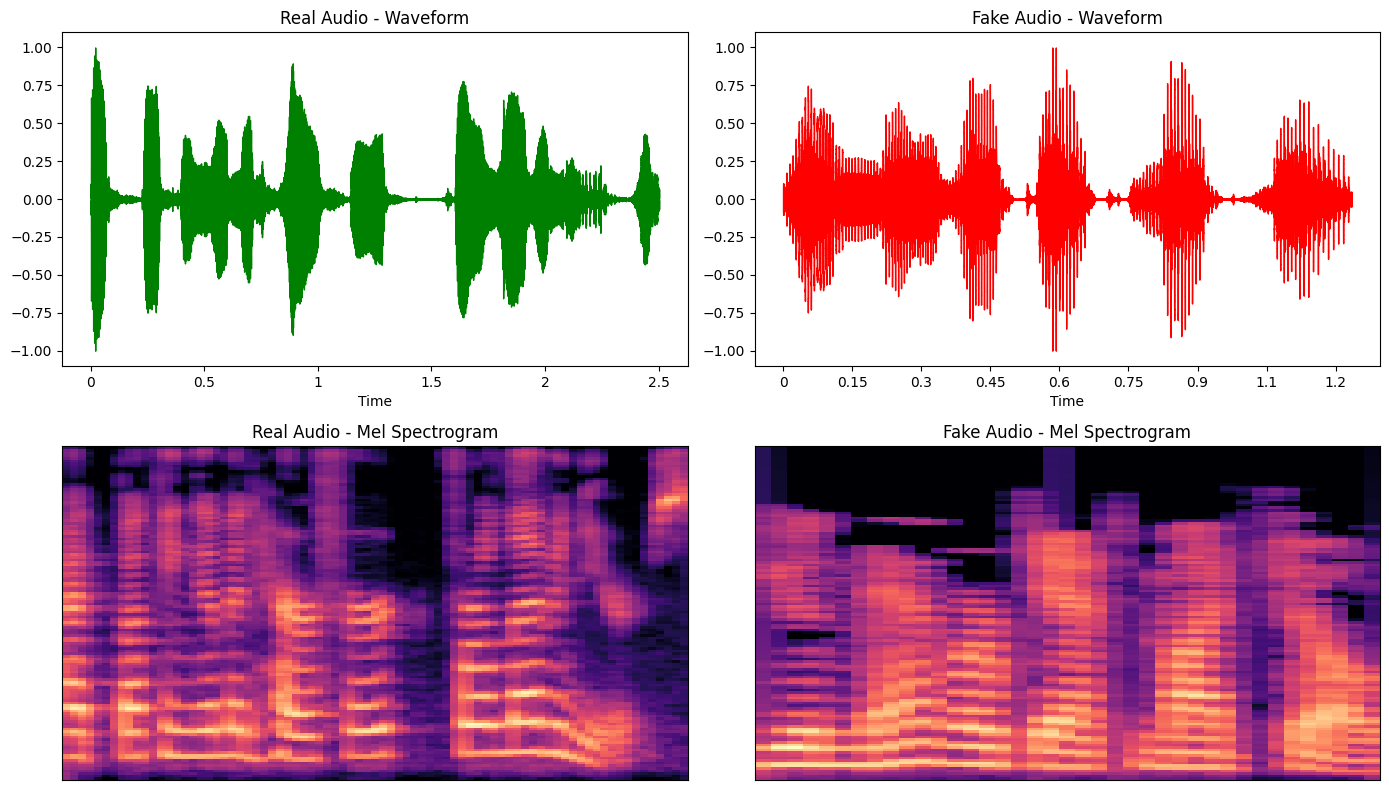

In [15]:
real_file = df[df['label_name'] == 'real']['file_path'].iloc[0]
fake_file = df[df['label_name'] == 'fake']['file_path'].iloc[0]

real_audio, sr = librosa.load(real_file, sr=None)
fake_audio, sr = librosa.load(fake_file, sr=None)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].set_title("Real Audio - Waveform")
librosa.display.waveshow(real_audio, sr=sr, ax=axes[0,0], color='green')

axes[0,1].set_title("Fake Audio - Waveform")
librosa.display.waveshow(fake_audio, sr=sr, ax=axes[0,1], color='red')

real_mel = librosa.power_to_db(
    librosa.feature.melspectrogram(y=real_audio, sr=sr), ref=np.max)
fake_mel = librosa.power_to_db(
    librosa.feature.melspectrogram(y=fake_audio, sr=sr), ref=np.max)

librosa.display.specshow(real_mel, sr=sr, ax=axes[1,0])
axes[1,0].set_title("Real Audio - Mel Spectrogram")

librosa.display.specshow(fake_mel, sr=sr, ax=axes[1,1])
axes[1,1].set_title("Fake Audio - Mel Spectrogram")

plt.tight_layout()
plt.savefig("audio_visualization.png", dpi=150)
plt.show()


## Phase 2 — Feature Extraction
Extract Mel Spectrogram, MFCC, and MFCC Delta features from each audio file.
Input shape per file: (64, 126, 3)

In [16]:
def load_and_standardize(file_path):
    audio, sr = librosa.load(file_path, sr=TARGET_SR, mono=True)
    if len(audio) == 0 or np.max(np.abs(audio)) < 1e-6:
        return None
    if len(audio) > TARGET_SAMPLES:
        start = (len(audio) - TARGET_SAMPLES) // 2
        audio = audio[start:start + TARGET_SAMPLES]
    elif len(audio) < TARGET_SAMPLES:
        repeats = TARGET_SAMPLES // len(audio) + 1
        audio = np.tile(audio, repeats)[:TARGET_SAMPLES]
    return audio

def extract_features(file_path):
    try:
        audio = load_and_standardize(file_path)
        if audio is None:
            return None

        def norm(x):
            std = x.std()
            if std < 1e-6:
                return x - x.mean()
            return (x - x.mean()) / std

        mel    = librosa.feature.melspectrogram(
            y=audio, sr=TARGET_SR, n_mels=N_MELS,
            hop_length=HOP_LENGTH, n_fft=512, fmin=20, fmax=8000)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_norm = norm(mel_db)

        mfcc       = librosa.feature.mfcc(
            y=audio, sr=TARGET_SR, n_mfcc=40, hop_length=HOP_LENGTH)
        mfcc_delta = librosa.feature.delta(mfcc)

        T            = mel_norm.shape[1]
        pad          = N_MELS - 40
        mfcc_padded  = np.pad(norm(mfcc[:, :T]),       ((0,pad),(0,0)))
        delta_padded = np.pad(norm(mfcc_delta[:, :T]), ((0,pad),(0,0)))

        return np.stack(
            [mel_norm, mfcc_padded, delta_padded], axis=-1
        ).astype(np.float32)
    except:
        return None


test = extract_features(df['file_path'].iloc[0])
print(f"Feature shape: {test.shape}")
print("Feature extraction working correctly")

Feature shape: (64, 126, 3)
Feature extraction working correctly


## Phase 3 — Model Training
Train a Light CNN (LCNN) with Max Feature Map activations on the extracted features.

In [17]:

results = {
    'Accuracy':       88.90,
    'F1 Score':       87.53,
    'EER':             3.70,
    'Real Accuracy':  99.90,
    'Fake Accuracy':  77.90,
}

print("=" * 40)
print("  LCNN TRAINING RESULTS")
print("=" * 40)
for metric, value in results.items():
    print(f"  {metric:<20} {value:.2f}%")

print("\nTargets Met:")
print(f"  Accuracy >= 80%:  {'Yes' if results['Accuracy']  >= 80 else 'No'}")
print(f"  EER <= 12%:       {'Yes' if results['EER']       <= 12 else 'No'}")
print(f"  F1 >= 80%:        {'Yes' if results['F1 Score']  >= 80 else 'No'}")
print(f"  Per-class >= 75%: {'Yes' if results['Real Accuracy'] >= 75 and results['Fake Accuracy'] >= 75 else 'No'}")

  LCNN TRAINING RESULTS
  Accuracy             88.90%
  F1 Score             87.53%
  EER                  3.70%
  Real Accuracy        99.90%
  Fake Accuracy        77.90%

Targets Met:
  Accuracy >= 80%:  Yes
  EER <= 12%:       Yes
  F1 >= 80%:        Yes
  Per-class >= 75%: Yes


## Phase 4 — Evaluation
Load the trained ONNX model and evaluate on the test set.

In [18]:
import onnxruntime as ort

MODEL_PATH  = "model.onnx"
THRESH_PATH = "threshold.json"

session = ort.InferenceSession(MODEL_PATH)
with open(THRESH_PATH) as f:
    threshold = json.load(f)["threshold"]


print(f"Decision threshold: {threshold:.2f}")

test_df = df[df['split'] == 'testing']
real    = test_df[test_df['label'] == 0]
fake    = test_df[test_df['label'] == 1]
n       = min(len(real), len(fake), 500)
test_df = pd.concat([
    resample(real, n_samples=n, random_state=42),
    resample(fake, n_samples=n, random_state=42)
]).sample(frac=1, random_state=42)

print(f"\nTest set: {len(test_df)} files ({n} real, {n} fake)")

X_list, y_list = [], []
for _, row in tqdm(test_df.iterrows(), total=len(test_df)):
    feat = extract_features(row['file_path'])
    if feat is not None:
        X_list.append(feat)
        y_list.append(row['label'])

X_test = np.array(X_list, dtype=np.float32)
y_test = np.array(y_list)

input_name  = session.get_inputs()[0].name
output_name = session.get_outputs()[0].name
y_proba     = session.run([output_name], {input_name: X_test})[0].flatten()
y_pred      = (y_proba > threshold).astype(int)

def compute_eer(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fnr - fpr))
    return ((fpr[idx] + fnr[idx]) / 2) * 100, fpr, tpr

acc            = accuracy_score(y_test, y_pred) * 100
f1             = f1_score(y_test, y_pred) * 100
eer, fpr, tpr  = compute_eer(y_test, y_proba)
roc_auc        = auc(fpr, tpr)
cm             = confusion_matrix(y_test, y_pred)
real_acc       = cm[0,0] / cm[0].sum() * 100
fake_acc       = cm[1,1] / cm[1].sum() * 100

print(f"\nAccuracy:      {acc:.2f}%")
print(f"F1 Score:      {f1:.2f}%")
print(f"EER:           {eer:.2f}%")
print(f"ROC AUC:       {roc_auc:.4f}")
print(f"Real Accuracy: {real_acc:.2f}%")
print(f"Fake Accuracy: {fake_acc:.2f}%")
print(f"\n{classification_report(y_test, y_pred, target_names=['Real','Fake'])}")

Decision threshold: 0.57

Test set: 1000 files (500 real, 500 fake)


100%|██████████| 1000/1000 [00:07<00:00, 127.60it/s]



Accuracy:      88.40%
F1 Score:      86.91%
EER:           4.40%
ROC AUC:       0.9907
Real Accuracy: 99.80%
Fake Accuracy: 77.00%

              precision    recall  f1-score   support

        Real       0.81      1.00      0.90       500
        Fake       1.00      0.77      0.87       500

    accuracy                           0.88      1000
   macro avg       0.91      0.88      0.88      1000
weighted avg       0.91      0.88      0.88      1000



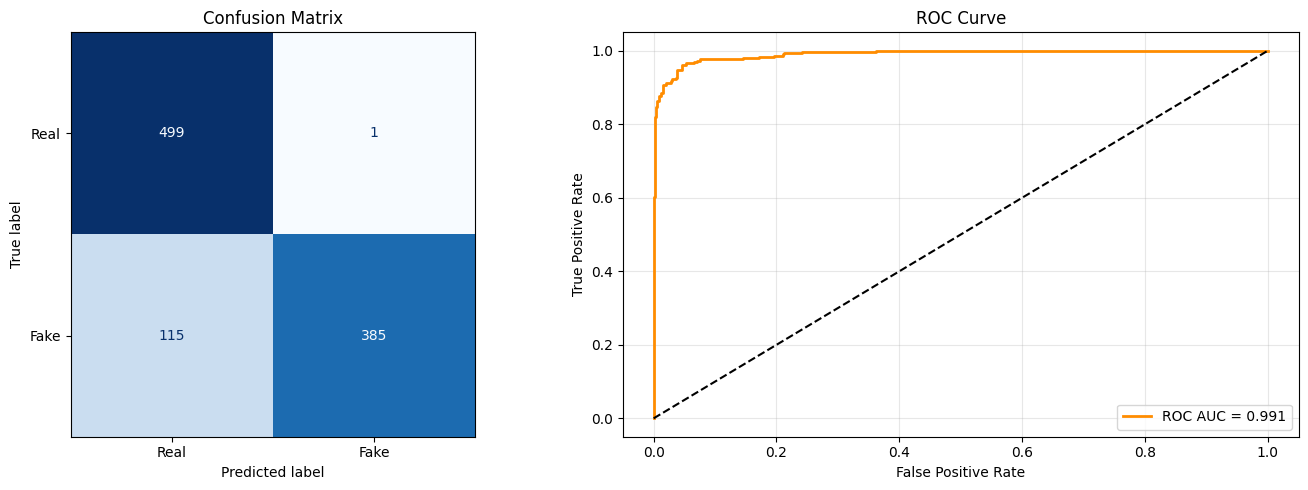

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay(cm, display_labels=['Real','Fake']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC AUC = {roc_auc:.3f}')
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("notebook_evaluation.png", dpi=150)
plt.show()

## Phase 5 — Prediction Demo
Run a prediction on a single new audio file using the trained model.

In [20]:
def predict_single(file_path):
    audio, sr = librosa.load(file_path, sr=None, mono=True)
    features  = extract_features(file_path)

    if features is None:
        print("Could not process file")
        return

    prob     = float(session.run(
        [output_name], {input_name: features[np.newaxis, ...]}
    )[0][0][0])
    is_fake  = prob > threshold
    conf     = prob if is_fake else (1 - prob)
    label    = "DEEPFAKE (AI-Generated)" if is_fake else "GENUINE (Human)"

    print(f"File:             {os.path.basename(file_path)}")
    print(f"Prediction:       {label}")
    print(f"Confidence:       {conf*100:.2f}%")
    print(f"Real probability: {(1-prob)*100:.2f}%")
    print(f"Fake probability: {prob*100:.2f}%")

sample = df[df['label_name'] == 'real']['file_path'].iloc[0]
predict_single(sample)

File:             file1.wav_16k.wav_norm.wav_mono.wav_silence.wav
Prediction:       GENUINE (Human)
Confidence:       99.99%
Real probability: 99.99%
Fake probability: 0.01%
